In [16]:


import os
import urllib.request
import bz2
import random
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import dlib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from skimage.feature import local_binary_pattern

print(" All libraries installed and imported successfully!")

 All libraries installed and imported successfully!


In [17]:
QUICK_TEST = False 
NUM_SUBJECTS = 50
IMG_W, IMG_H = 150, 150

DATASET_PATH = r"D:\collage\lv3\Sem2\Biometrics\[BIOM S'26] Project Resources\NEW\Project\gt_db"
SAVE_PATH = r"D:\collage\lv3\Sem2\Biometrics\[BIOM S'26] Project Resources\NEW\Project\data"

import os
os.makedirs(SAVE_PATH, exist_ok=True)
import random
random.seed(42) 

print(" Configuration set.")

 Configuration set.


In [ ]:
DAT_FILE = "shape_predictor_68_face_landmarks.dat"
if not os.path.exists(DAT_FILE):
    print("Downloading shape predictor...")
    url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
    urllib.request.urlretrieve(url, DAT_FILE + ".bz2")
    with bz2.BZ2File(DAT_FILE + ".bz2") as fr, open(DAT_FILE, "wb") as fw:
        fw.write(fr.read())
    os.remove(DAT_FILE + ".bz2")

# ── 2. Initialize Models 
DLIB_LANDMARK_PREDICTOR = dlib.shape_predictor(DAT_FILE)
DLIB_DETECTOR = dlib.get_frontal_face_detector()
FACE_ALT = cv.CascadeClassifier(cv.data.haarcascades + "haarcascade_frontalface_alt.xml")
EYE_CASCADE = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_eye.xml')

# ── 3. Helper Functions
def _rect_to_xywh(rect):
    x, y = rect.left(), rect.top()
    return int(x), int(y), int(rect.right()-x), int(rect.bottom()-y)

def _is_valid_face(x, y, w, h, img_w, img_h):
    if w < 35 or h < 35 or w < img_w * 0.03 or h < img_h * 0.03: return False
    aspect = w / h
    if aspect < 0.45 or aspect > 2.2: return False
    return True

def detect_face_fast(bgr):
    img_h, img_w = bgr.shape[:2]
    dlib_rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    dlib_faces = DLIB_DETECTOR(dlib_rgb, 0)
    
    if len(dlib_faces) > 0:
        dlib_faces = sorted(dlib_faces, key=lambda r: r.width() * r.height(), reverse=True)
        x, y, w, h = _rect_to_xywh(dlib_faces[0])
        x, y = max(0, x), max(0, y)
        w, h = min(w, img_w - x), min(h, img_h - y)
        if _is_valid_face(x, y, w, h, img_w, img_h): return (x, y, w, h)
        
    # Fallback to Haar Cascade
    gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    gray_eq = cv.equalizeHist(gray)
    cv_faces = FACE_ALT.detectMultiScale(gray_eq, scaleFactor=1.05, minNeighbors=4, minSize=(35, 35))
    if len(cv_faces) > 0:
        cv_faces = sorted(cv_faces, key=lambda r: r[2] * r[3], reverse=True)
        x, y, w, h = cv_faces[0]
        if _is_valid_face(x, y, w, h, img_w, img_h): return (int(x), int(y), int(w), int(h))
    return None

def align_face(gray_face):
    h, w = gray_face.shape
    faces = DLIB_DETECTOR(gray_face, 0)
    face_rect = faces[0] if len(faces) > 0 else dlib.rectangle(0, 0, w, h)
    
    landmarks = DLIB_LANDMARK_PREDICTOR(gray_face, face_rect)
    eye1_pts = np.array([(landmarks.part(i).x, landmarks.part(i).y) for i in range(36, 42)])
    eye2_pts = np.array([(landmarks.part(i).x, landmarks.part(i).y) for i in range(42, 48)])
    
    eye1_center = eye1_pts.mean(axis=0).astype(int)
    eye2_center = eye2_pts.mean(axis=0).astype(int)
    
    eyes = sorted([eye1_center, eye2_center], key=lambda e: e[0])
    dy = eyes[1][1] - eyes[0][1]
    dx = eyes[1][0] - eyes[0][0]
    angle = np.degrees(np.arctan2(dy, dx))
    
    M = cv.getRotationMatrix2D((w // 2, h // 2), angle, scale=1.0)
    return cv.warpAffine(gray_face, M, (w, h), flags=cv.INTER_LINEAR, borderMode=cv.BORDER_REFLECT)

print(" Dlib Alignment Functions Ready")

✓ Dlib Alignment Functions Ready


In [ ]:
subjects_to_run = range(1, 7) if QUICK_TEST else range(1, NUM_SUBJECTS + 1)
tasks = [(sid, img_num) for sid in subjects_to_run for img_num in range(1, 16)]

X_all_raw, y_all, failed = [], [], []
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

print(f" Processing {len(tasks)} images...")

for idx, (subject_id, img_num) in enumerate(tasks):
    img_path = os.path.join(DATASET_PATH, f's{subject_id:02d}', f'{img_num:02d}.jpg')
    
    # 1. Check if the file actually exists on your hard drive
    if not os.path.exists(img_path):
        print(f"⚠ PATH NOT FOUND: {img_path}")
        continue
        
    # 2. Bulletproof reading method for paths with special characters [ ] '
    img_array = np.fromfile(img_path, np.uint8)
    bgr = cv.imdecode(img_array, cv.IMREAD_COLOR)
    
    if bgr is None:
        print(f" Could not decode image: {img_path}")
        continue
        
    result = detect_face_fast(bgr)
    
    if result is not None:
        x, y, w, h = result
        pad = 15
        ih, iw = bgr.shape[:2]
        face_crop = bgr[max(0, y-pad) : min(ih, y+h+pad), max(0, x-pad) : min(iw, x+w+pad)]
    else:
        failed.append(f's{subject_id:02d}/{img_num:02d}.jpg')
        face_crop = bgr
        
    face_gray = cv.cvtColor(face_crop, cv.COLOR_BGR2GRAY)
    
    # Illumination Normalization
    face_gray = clahe.apply(face_gray)
    
    # Alignment
    try:
        face_gray = align_face(face_gray)
    except Exception:
        # Fallback Eye Alignment
        eyes = EYE_CASCADE.detectMultiScale(face_gray, scaleFactor=1.1, minNeighbors=5)
        if len(eyes) >= 2:
            eyes = sorted(eyes, key=lambda e: e[0])[:2]
            dy = (eyes[1][1] + eyes[1][3]//2) - (eyes[0][1] + eyes[0][3]//2)
            dx = (eyes[1][0] + eyes[1][2]//2) - (eyes[0][0] + eyes[0][2]//2)
            M = cv.getRotationMatrix2D((face_gray.shape[1]//2, face_gray.shape[0]//2), np.degrees(np.arctan2(dy, dx)), 1.0)
            face_gray = cv.warpAffine(face_gray, M, (face_gray.shape[1], face_gray.shape[0]), flags=cv.INTER_LINEAR, borderMode=cv.BORDER_REFLECT)

    face_resized = cv.resize(face_gray, (IMG_W, IMG_H))
    X_all_raw.append(face_resized)
    y_all.append(subject_id - 1)
    
    if (idx + 1) % 100 == 0:
        print(f" ... Processed {idx + 1}/{len(tasks)} images")

X_all_raw = np.array(X_all_raw, dtype=np.uint8)
y_all = np.array(y_all)

# ── 80/20 Split ──
if len(X_all_raw) == 0:
    print("\n CRITICAL ERROR: 0 images were loaded. Please check your DATASET_PATH.")
else:
    X_train_raw, y_train, X_test_raw, y_test = [], [], [], []
    for sid in range(len(subjects_to_run)):
        indices = list(np.where(y_all == sid)[0])
        random.shuffle(indices)
        split = int(len(indices) * 0.8)
        
        X_train_raw.extend(X_all_raw[i] for i in indices[:split])
        y_train.extend(y_all[i] for i in indices[:split])
        X_test_raw.extend(X_all_raw[i] for i in indices[split:])
        y_test.extend(y_all[i] for i in indices[split:])

    X_train_raw, X_test_raw = np.array(X_train_raw), np.array(X_test_raw)
    y_train, y_test = np.array(y_train), np.array(y_test)

    # Save labels
    np.save(os.path.join(SAVE_PATH, 'y_train.npy'), y_train)
    np.save(os.path.join(SAVE_PATH, 'y_test.npy'), y_test)

    print(f" Processing complete. Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")

 Processing 750 images...
 ... Processed 100/750 images
 ... Processed 200/750 images
 ... Processed 300/750 images
 ... Processed 400/750 images
 ... Processed 500/750 images
 ... Processed 600/750 images
 ... Processed 700/750 images
✓ Processing complete. Train: (600, 150, 150), Test: (150, 150, 150)


In [20]:
X_train_proc = X_train_raw.astype(np.float64) / 255.0
X_test_proc = X_test_raw.astype(np.float64) / 255.0

mean_face = X_train_proc.mean(axis=0)
X_train = X_train_proc - mean_face
X_test = X_test_proc - mean_face

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f" Images Flattened & Normalized. Flat Train Shape: {X_train_flat.shape}")

 Images Flattened & Normalized. Flat Train Shape: (600, 22500)


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

pca = PCA(n_components=400, whiten=True, random_state=42)
train_pca_full = pca.fit_transform(X_train_scaled)
test_pca_full = pca.transform(X_test_scaled)

# Drop first 3 components to ignore heavy lighting variations (improves accuracy)
train_features_pca = train_pca_full[:, 3:]
test_features_pca = test_pca_full[:, 3:]

np.save(os.path.join(SAVE_PATH, 'train_features_pca.npy'), train_features_pca)
np.save(os.path.join(SAVE_PATH, 'test_features_pca.npy'), test_features_pca)

print(f" PCA Features Extracted and Saved. Final shape: {train_features_pca.shape}")

 PCA Features Extracted and Saved. Final shape: (600, 397)


In [22]:
def extract_lbp_grid(images, P=8, R=1, grid_x=8, grid_y=8):
    features = []
    print(f" Extracting LBP features for {len(images)} images...")
    for idx, img in enumerate(images):
        lbp = local_binary_pattern(img, P, R, method="uniform")
        h, w = img.shape
        cell_h, cell_w = h // grid_y, w // grid_x
        
        hist_grid = []
        for i in range(grid_y):
            for j in range(grid_x):
                cell = lbp[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
                hist, _ = np.histogram(cell, bins=P+2, range=(0, P+2), density=True)
                hist_grid.extend(hist)
        features.append(hist_grid)
        
        if (idx + 1) % 100 == 0:
            print(f" ... {idx + 1}/{len(images)} done")
            
    return np.array(features)

# Extract from raw arrays for better spatial histograms
train_features_lbp = extract_lbp_grid(X_train_raw)
test_features_lbp = extract_lbp_grid(X_test_raw)

# Scale LBP features (crucial for SVM matcher accuracy)
lbp_scaler = StandardScaler()
train_features_lbp = lbp_scaler.fit_transform(train_features_lbp)
test_features_lbp = lbp_scaler.transform(test_features_lbp)

np.save(os.path.join(SAVE_PATH, 'train_features_lbp.npy'), train_features_lbp)
np.save(os.path.join(SAVE_PATH, 'test_features_lbp.npy'), test_features_lbp)

print(f" LBP Features Extracted, Scaled and Saved. Final shape: {train_features_lbp.shape}")

 Extracting LBP features for 600 images...
 ... 100/600 done
 ... 200/600 done
 ... 300/600 done
 ... 400/600 done
 ... 500/600 done
 ... 600/600 done
 Extracting LBP features for 150 images...
 ... 100/150 done
 LBP Features Extracted, Scaled and Saved. Final shape: (600, 640)


In [23]:
import torch
from facenet_pytorch import InceptionResnetV1
import torchvision.transforms as transforms
from PIL import Image

print(" Loading FaceNet Model...")
# Automatically use GPU if available, otherwise fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the model trained specifically to distinguish human faces
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# FaceNet expects images resized to 160x160 and normalized (mean=0.5, std=0.5)
preprocess = transforms.Compose([
    transforms.Resize((160, 160)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def extract_facenet_features(raw_images):
    print(f" Extracting FaceNet features for {len(raw_images)} images...")
    features = []
    
    with torch.no_grad():
        for idx, img in enumerate(raw_images):
            # Convert grayscale (uint8) back to 3-channel RGB for the CNN
            img_rgb = cv.cvtColor(img, cv.COLOR_GRAY2RGB)
            img_pil = Image.fromarray(img_rgb)
            
            # Preprocess and add batch dimension [1, 3, 160, 160]
            img_tensor = preprocess(img_pil).unsqueeze(0).to(device)
            
            # Extract 512-dimensional embedding
            embedding = resnet(img_tensor)
            features.append(embedding.squeeze().cpu().numpy())
            
            if (idx + 1) % 100 == 0:
                print(f" ... {idx + 1}/{len(raw_images)} done")
                
    return np.array(features)

# Extract Features using the RAW images
train_features_cnn = extract_facenet_features(X_train_raw)
test_features_cnn = extract_facenet_features(X_test_raw)

# Save the ultimate features
np.save(os.path.join(SAVE_PATH, 'train_features_cnn.npy'), train_features_cnn)
np.save(os.path.join(SAVE_PATH, 'test_features_cnn.npy'), test_features_cnn)

print(f" Ultimate FaceNet Features Extracted and Saved.")
print(f"  Shape: {train_features_cnn.shape} -> Expected (X, 512)")

 Loading FaceNet Model...
 Extracting FaceNet features for 600 images...
 ... 100/600 done
 ... 200/600 done
 ... 300/600 done
 ... 400/600 done
 ... 500/600 done
 ... 600/600 done
 Extracting FaceNet features for 150 images...
 ... 100/150 done
 Ultimate FaceNet Features Extracted and Saved.
  Shape: (600, 512) -> Expected (X, 512)


In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print(" Evaluating Feature Extractors with Linear SVM...\n")

# 1. Evaluate PCA
svm_pca = SVC(kernel='linear', C=1.0)
svm_pca.fit(train_features_pca, y_train)
acc_pca = accuracy_score(y_test, svm_pca.predict(test_features_pca))
print(f" Phase 1: PCA Accuracy         = {acc_pca * 100:.2f}%")

# 2. Evaluate LBP
svm_lbp = SVC(kernel='linear', C=1.0)
svm_lbp.fit(train_features_lbp, y_train)
acc_lbp = accuracy_score(y_test, svm_lbp.predict(test_features_lbp))
print(f" Phase 2: LBP Accuracy         = {acc_lbp * 100:.2f}%")

# 3. Evaluate FaceNet (CNN)
svm_cnn = SVC(kernel='linear', C=1.0)
svm_cnn.fit(train_features_cnn, y_train)
acc_cnn = accuracy_score(y_test, svm_cnn.predict(test_features_cnn))
print(f" Phase 3: FaceNet CNN Accuracy = {acc_cnn * 100:.2f}%")

print("\n✓ Feature Extraction Pipeline is 100% Complete and Verified!")

 Evaluating Feature Extractors with Linear SVM...

 Phase 1: PCA Accuracy         = 54.67%
 Phase 2: LBP Accuracy         = 82.67%
 Phase 3: FaceNet CNN Accuracy = 100.00%

✓ Feature Extraction Pipeline is 100% Complete and Verified!


 Testing Outside Image: D:\collage\lv3\Sem2\Biometrics\[BIOM S'26] Project Resources\NEW\Project\Samples\WhatsApp Image 2026-05-15 at 5.19.56 PM.jpeg

 SYSTEM PREDICTION:
   This face belongs to: Subject s28



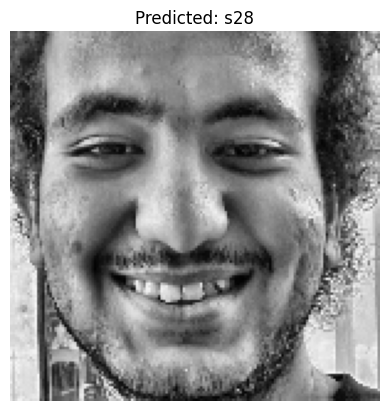

In [29]:
import os
import cv2 as cv
import numpy as np
import torch
from PIL import Image

# ── 1. PUT YOUR TEST IMAGE PATH HERE ──
TEST_IMAGE_PATH = r"D:\collage\lv3\Sem2\Biometrics\[BIOM S'26] Project Resources\NEW\Project\Samples\WhatsApp Image 2026-05-15 at 5.19.56 PM.jpeg"
print(f" Testing Outside Image: {TEST_IMAGE_PATH}")

if not os.path.exists(TEST_IMAGE_PATH):
    print(" ERROR: Image not found. Please check the path.")
else:
    # ── 2. Read, Detect, and Align ──
    # Bypass OpenCV path bugs
    img_array = np.fromfile(TEST_IMAGE_PATH, np.uint8)
    bgr = cv.imdecode(img_array, cv.IMREAD_COLOR)
    
    result = detect_face_fast(bgr)
    
    if result is not None:
        x, y, w, h = result
        pad = 15
        ih, iw = bgr.shape[:2]
        face_crop = bgr[max(0, y-pad) : min(ih, y+h+pad), max(0, x-pad) : min(iw, x+w+pad)]
        
        face_gray = cv.cvtColor(face_crop, cv.COLOR_BGR2GRAY)
        face_gray = clahe.apply(face_gray)
        
        try:
            face_gray = align_face(face_gray)
        except Exception:
            pass # Use as-is if fallback alignment fails
            
        face_resized = cv.resize(face_gray, (IMG_W, IMG_H))
        
        # ── 3. FaceNet Feature Extraction ──
        img_rgb = cv.cvtColor(face_resized, cv.COLOR_GRAY2RGB)
        img_pil = Image.fromarray(img_rgb)
        
        img_tensor = preprocess(img_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            embedding = resnet(img_tensor).squeeze().cpu().numpy()
            
        # ── 4. SVM Prediction ──
        # We must reshape the embedding from (512,) to (1, 512) for the SVM
        embedding_reshaped = embedding.reshape(1, -1)
        
        predicted_class = svm_cnn.predict(embedding_reshaped)[0]
        confidence = svm_cnn.decision_function(embedding_reshaped)
        
        # Output the result
        print("\n" + "="*50)
        print(f" SYSTEM PREDICTION:")
        print(f"   This face belongs to: Subject s{predicted_class + 1:02d}")
        print("="*50 + "\n")
        
        # Display the cropped face to verify it worked
        plt.imshow(img_rgb)
        plt.title(f"Predicted: s{predicted_class + 1:02d}")
        plt.axis('off')
        plt.show()
        
    else:
        print(" SYSTEM COULD NOT DETECT A FACE IN THIS IMAGE.")

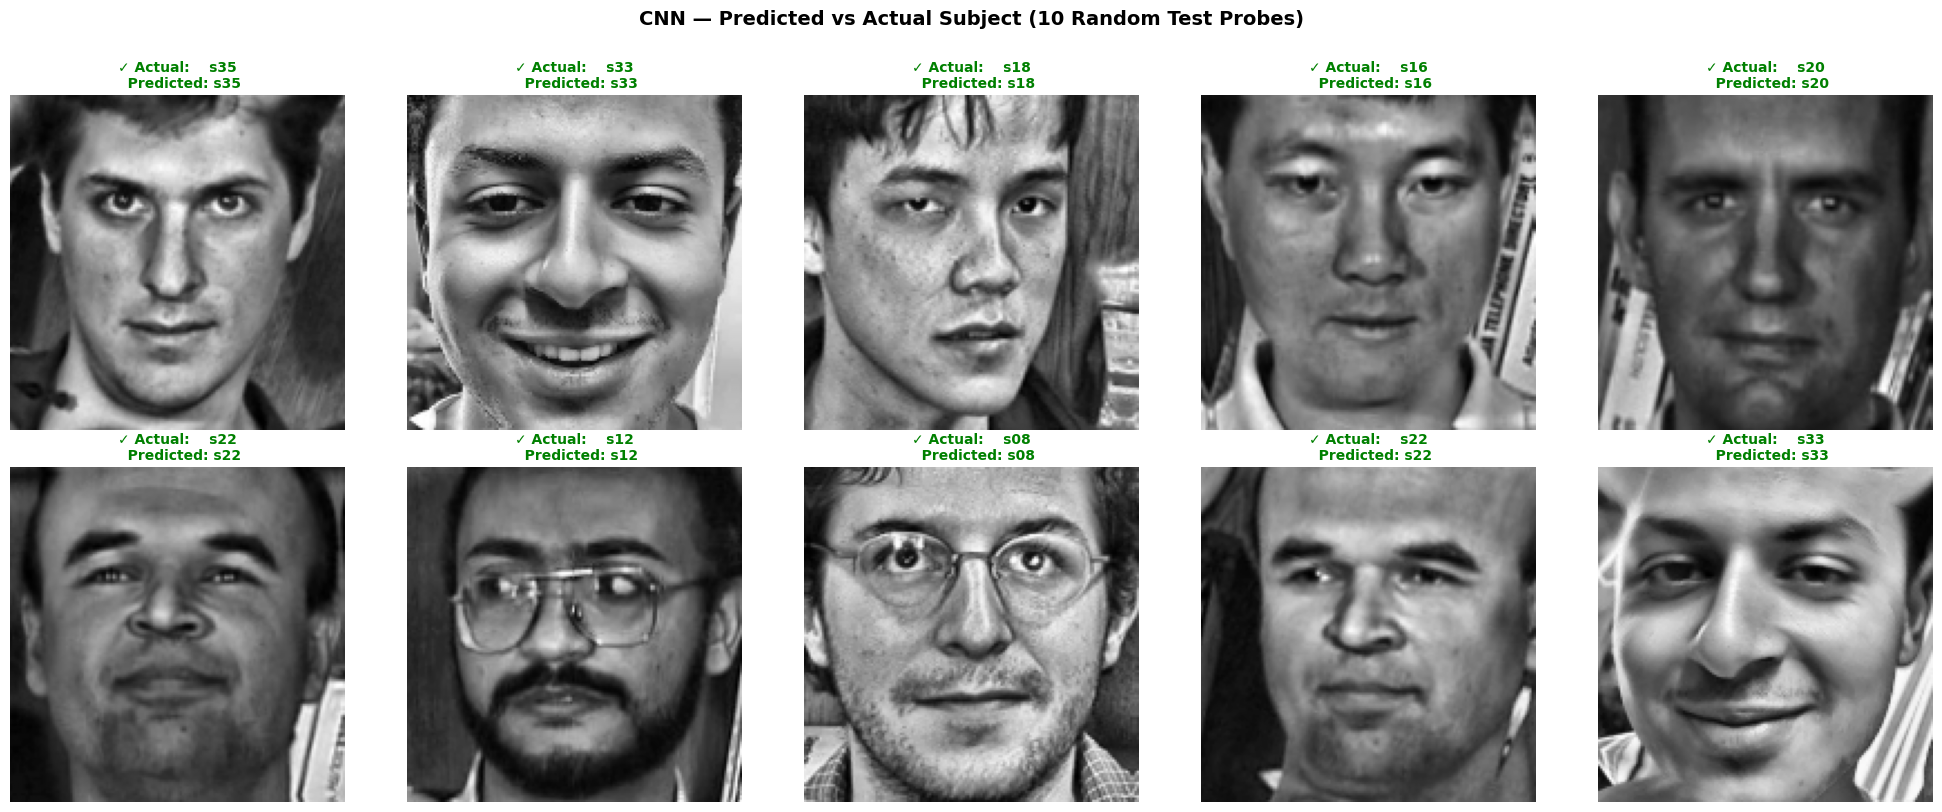


 Accuracy on these 10 probes: 10/10 correct


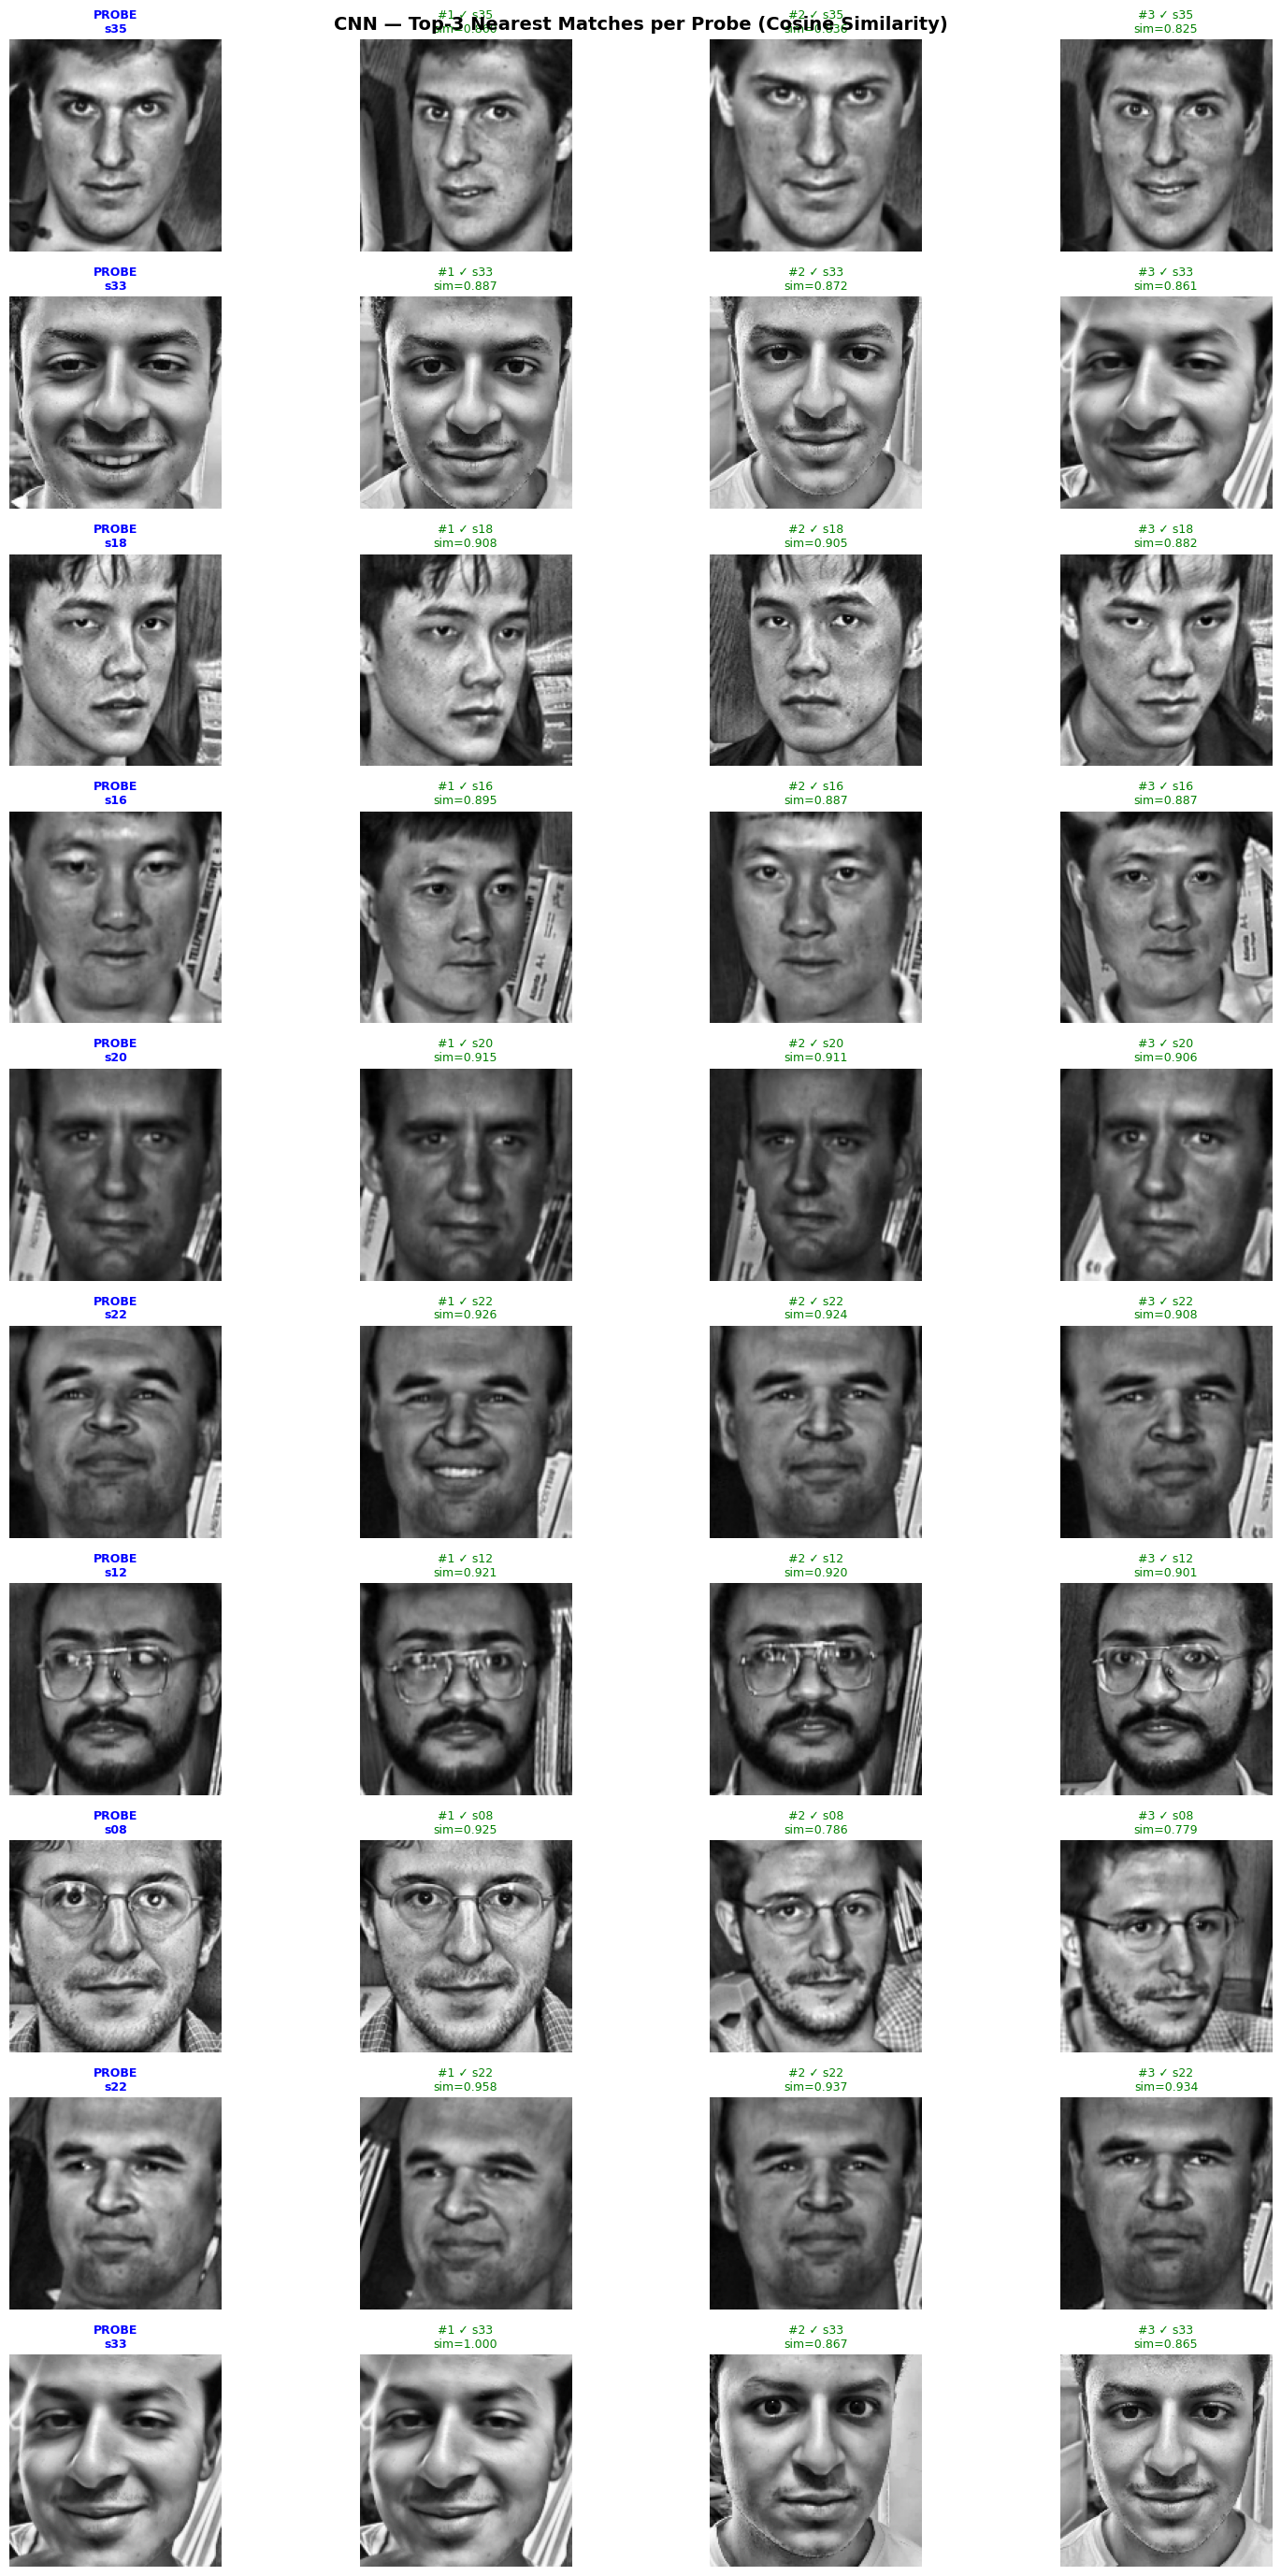


 Both figures saved:
   cnn_predicted_vs_actual.png
   cnn_top3_matches.png


In [26]:
# ─── CNN VISUALIZATION: Predictions + Top-3 Matches ───
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import random

# ── Load saved CNN features ──────────────────────
train_cnn    = np.load('data/train_features_cnn.npy')   # (600, 1280)
test_cnn     = np.load('data/test_features_cnn.npy')    # (150, 1280)
y_train      = np.load('data/y_train.npy')
y_test       = np.load('data/y_test.npy')

# ── Pick 10 random test probes ─
random.seed(99)
probe_indices = random.sample(range(len(X_test_raw)), 10)

# ── Cosine similarity matcher ────
def predict_cosine(probe_feat, train_feats, train_labels):
    sims       = cosine_similarity([probe_feat], train_feats)[0]
    top3_idx   = np.argsort(sims)[::-1][:3]
    top3_sims  = sims[top3_idx]
    top3_labels= train_labels[top3_idx]
    predicted  = top3_labels[0]
    return predicted, top3_idx, top3_sims, top3_labels

# ── Figure 1: Predicted vs Actual (10 probes) ────────────────────────────────
fig1, axes = plt.subplots(2, 5, figsize=(20, 8))
fig1.suptitle('CNN — Predicted vs Actual Subject (10 Random Test Probes)',
              fontsize=14, fontweight='bold', y=1.01)

correct = 0
for plot_i, probe_idx in enumerate(probe_indices):
    ax = axes[plot_i // 5][plot_i % 5]

    probe_feat  = test_cnn[probe_idx]
    actual_id   = y_test[probe_idx]
    predicted_id, _, _, _ = predict_cosine(probe_feat, train_cnn, y_train)

    img = X_test_raw[probe_idx]
    ax.imshow(img, cmap='gray')
    ax.axis('off')

    is_correct = (predicted_id == actual_id)
    if is_correct:
        correct += 1

    color = 'green' if is_correct else 'red'
    mark  = '✓' if is_correct else '✗'
    ax.set_title(
        f"{mark} Actual:    s{actual_id+1:02d}\n"
        f"   Predicted: s{predicted_id+1:02d}",
        fontsize=10, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('cnn_predicted_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n Accuracy on these 10 probes: {correct}/10 correct")

# ── Figure 2: Top-3 Nearest Matches per Probe ────────────────────────────────
fig2, axes = plt.subplots(10, 4, figsize=(16, 28))
fig2.suptitle('CNN — Top-3 Nearest Matches per Probe (Cosine Similarity)',
              fontsize=14, fontweight='bold')

for row, probe_idx in enumerate(probe_indices):
    probe_feat   = test_cnn[probe_idx]
    actual_id    = y_test[probe_idx]
    predicted_id, top3_idx, top3_sims, top3_labels = predict_cosine(
        probe_feat, train_cnn, y_train)

    # Column 0: probe image
    ax = axes[row][0]
    ax.imshow(X_test_raw[probe_idx], cmap='gray')
    ax.axis('off')
    ax.set_title(f'PROBE\ns{actual_id+1:02d}', fontsize=9,
                 fontweight='bold', color='blue')

    # Columns 1-3: top-3 matches from training set
    for col, (t_idx, sim, t_label) in enumerate(
            zip(top3_idx, top3_sims, top3_labels), start=1):
        ax = axes[row][col]
        ax.imshow(X_train_raw[t_idx], cmap='gray')
        ax.axis('off')

        is_match = (t_label == actual_id)
        color    = 'green' if is_match else 'red'
        mark     = '✓' if is_match else '✗'
        ax.set_title(
            f'#{col} {mark} s{t_label+1:02d}\nsim={sim:.3f}',
            fontsize=9, color=color
        )

    # Row label on the left
    axes[row][0].set_ylabel(f'Probe {row+1}', fontsize=9, rotation=0,
                             labelpad=50, va='center')

plt.tight_layout()
plt.savefig('cnn_top3_matches.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n Both figures saved:")
print("   cnn_predicted_vs_actual.png")
print("   cnn_top3_matches.png")

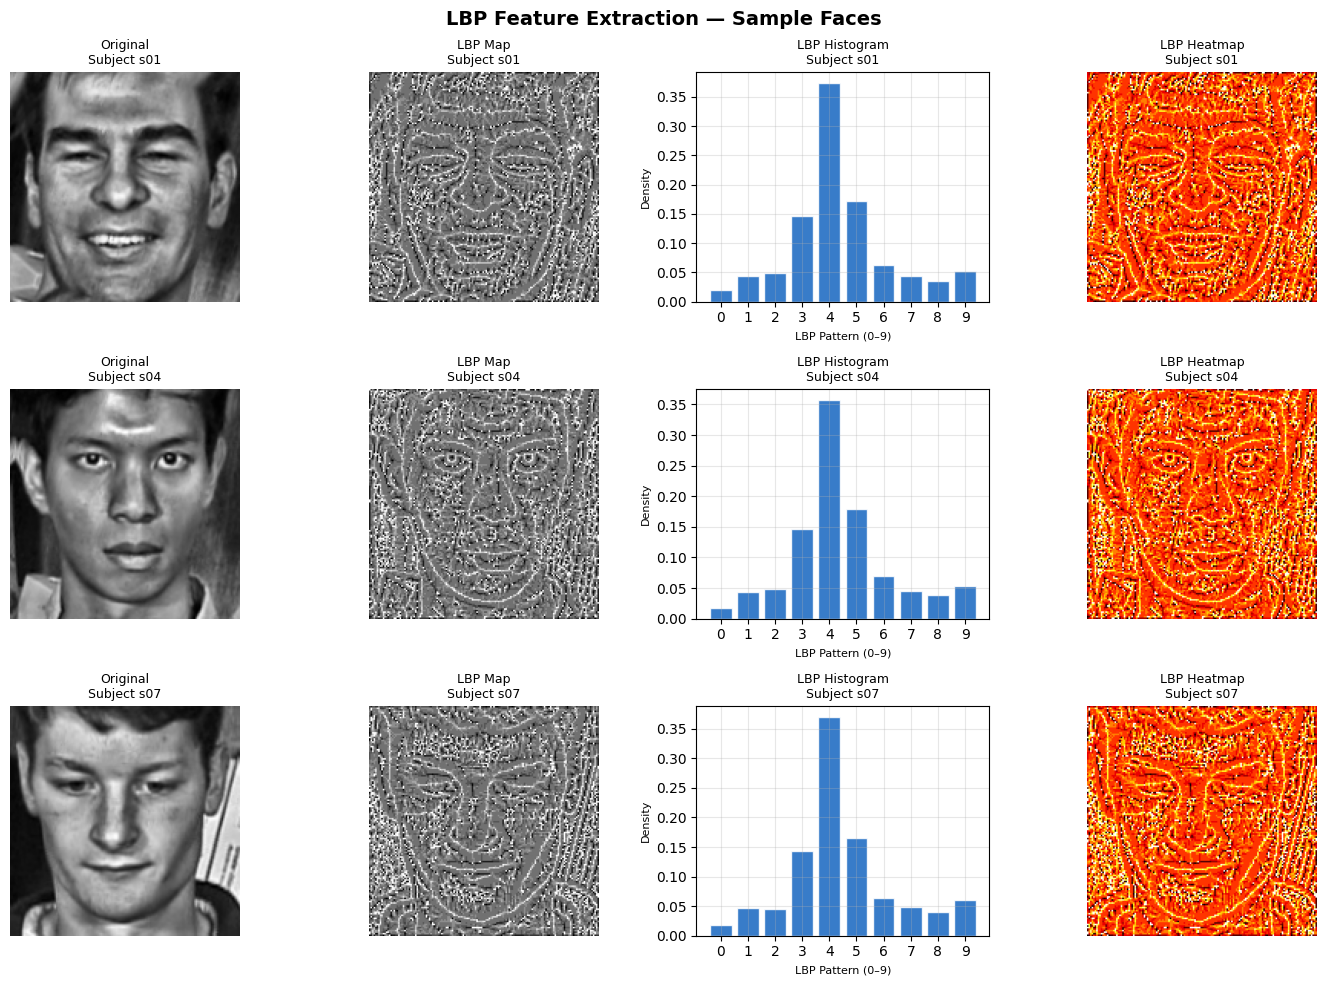

 LBP visualization saved: lbp_visualization.png


In [27]:
# ============================================================
#  LBP Visualization
# ============================================================
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
import numpy as np

RADIUS   = 1
N_POINTS = 8
METHOD   = 'uniform'
n_bins   = N_POINTS + 2  # = 10

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("LBP Feature Extraction — Sample Faces", fontsize=14, fontweight='bold')

sample_indices = [0, 40, 80]

for row, idx in enumerate(sample_indices):
    # --- Original face ---
    original = np.clip(X_train[idx] + mean_face, 0, 1)
    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 0].set_title(f"Original\nSubject s{y_train[idx]+1:02d}", fontsize=9)
    axes[row, 0].axis('off')

    # --- LBP map ---
    img_uint8 = np.clip((X_train[idx] + 0.5) * 255, 0, 255).astype(np.uint8)
    lbp_map   = local_binary_pattern(img_uint8, N_POINTS, RADIUS, METHOD)
    axes[row, 1].imshow(lbp_map, cmap='gray')
    axes[row, 1].set_title(f"LBP Map\nSubject s{y_train[idx]+1:02d}", fontsize=9)
    axes[row, 1].axis('off')

    # --- LBP histogram — CLAMPED to exactly 10 bins ---
    lbp_clamped = np.clip(lbp_map.ravel(), 0, n_bins - 1)  # ← key fix
    hist, _ = np.histogram(lbp_clamped, bins=n_bins,
                           range=(0, n_bins), density=True)
    axes[row, 2].bar(range(n_bins), hist, color='#1565C0',
                     edgecolor='white', alpha=0.85)
    axes[row, 2].set_title(f"LBP Histogram\nSubject s{y_train[idx]+1:02d}", fontsize=9)
    axes[row, 2].set_xlabel("LBP Pattern (0–9)", fontsize=8)
    axes[row, 2].set_ylabel("Density", fontsize=8)
    axes[row, 2].set_xticks(range(n_bins))
    axes[row, 2].grid(True, alpha=0.3)

    # --- LBP heatmap ---
    axes[row, 3].imshow(lbp_map, cmap='hot')
    axes[row, 3].set_title(f"LBP Heatmap\nSubject s{y_train[idx]+1:02d}", fontsize=9)
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('lbp_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(" LBP visualization saved: lbp_visualization.png")

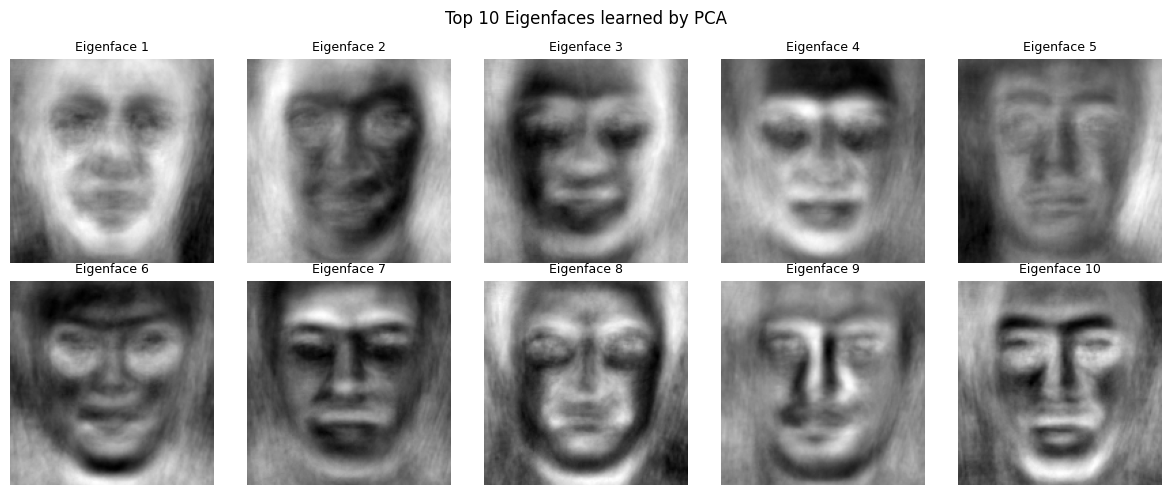

 Eigenfaces plotted


In [28]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    eigenface = pca.components_[i].reshape(IMG_H, IMG_W)    
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f"Eigenface {i+1}", fontsize=9)
    ax.axis('off')

plt.suptitle("Top 10 Eigenfaces learned by PCA", fontsize=12)
plt.tight_layout()
plt.show()
print(" Eigenfaces plotted")  #optional but good for reporr